<a href="https://colab.research.google.com/github/PrashanthiThirunahari/Projects/blob/main/SleepHealth_LifeStyle_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier

In [3]:
d=pd.read_csv('/content/Sleep_health_and_lifestyle_dataset.csv')
print(d)
d=d.fillna(0)

     Person ID  Gender  Age            Occupation  Sleep Duration  \
0            1    Male   27     Software Engineer             6.1   
1            2    Male   28                Doctor             6.2   
2            3    Male   28                Doctor             6.2   
3            4    Male   28  Sales Representative             5.9   
4            5    Male   28  Sales Representative             5.9   
..         ...     ...  ...                   ...             ...   
369        370  Female   59                 Nurse             8.1   
370        371  Female   59                 Nurse             8.0   
371        372  Female   59                 Nurse             8.1   
372        373  Female   59                 Nurse             8.1   
373        374  Female   59                 Nurse             8.1   

     Quality of Sleep  Physical Activity Level  Stress Level BMI Category  \
0                   6                       42             6   Overweight   
1                

In [4]:
y={"Sleep Apnea":1}

In [5]:
y={"Insomina":2}

In [6]:
y=["Sleep Disorder"]
print(y)

['Sleep Disorder']


In [7]:
d.isnull()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,False,False,False,False,False,False,False,False,False,False,False,False,False
370,False,False,False,False,False,False,False,False,False,False,False,False,False
371,False,False,False,False,False,False,False,False,False,False,False,False,False
372,False,False,False,False,False,False,False,False,False,False,False,False,False


In [8]:
d.shape

(374, 13)

In [9]:
y = d['Sleep Disorder']
print(y)

0                0
1                0
2                0
3      Sleep Apnea
4      Sleep Apnea
          ...     
369    Sleep Apnea
370    Sleep Apnea
371    Sleep Apnea
372    Sleep Apnea
373    Sleep Apnea
Name: Sleep Disorder, Length: 374, dtype: object


In [10]:
x = d.drop('Sleep Disorder', axis=1)
print(x)

     Person ID  Gender  Age            Occupation  Sleep Duration  \
0            1    Male   27     Software Engineer             6.1   
1            2    Male   28                Doctor             6.2   
2            3    Male   28                Doctor             6.2   
3            4    Male   28  Sales Representative             5.9   
4            5    Male   28  Sales Representative             5.9   
..         ...     ...  ...                   ...             ...   
369        370  Female   59                 Nurse             8.1   
370        371  Female   59                 Nurse             8.0   
371        372  Female   59                 Nurse             8.1   
372        373  Female   59                 Nurse             8.1   
373        374  Female   59                 Nurse             8.1   

     Quality of Sleep  Physical Activity Level  Stress Level BMI Category  \
0                   6                       42             6   Overweight   
1                

In [11]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
x['Gender']=le.fit_transform(x['Gender'])
x['Age']=le.fit_transform(x['Age'])
x['Occupation']=le.fit_transform(x['Occupation'])
y=y.astype(str)
y = le.fit_transform(y)
print(x)
print(y)

     Person ID  Gender  Age  Occupation  Sleep Duration  Quality of Sleep  \
0            1       1    0           9             6.1                 6   
1            2       1    1           1             6.2                 6   
2            3       1    1           1             6.2                 6   
3            4       1    1           6             5.9                 4   
4            5       1    1           6             5.9                 4   
..         ...     ...  ...         ...             ...               ...   
369        370       0   30           5             8.1                 9   
370        371       0   30           5             8.0                 9   
371        372       0   30           5             8.1                 9   
372        373       0   30           5             8.1                 9   
373        374       0   30           5             8.1                 9   

     Physical Activity Level  Stress Level BMI Category Blood Pressure  \
0

In [12]:
numerical_features = x.select_dtypes(include=['number'])
categorical_features = x.select_dtypes(exclude=['number'])


dd1 = (numerical_features - numerical_features.min()) / (numerical_features.max() - numerical_features.min())


dd1 = pd.concat([dd1, categorical_features], axis=1)

In [13]:
mapping = {"None":0,"Sleep Apnea": 1, "Insomina": 2}
y = pd.Series(y)
y = y.map(mapping)
print(y)

0     NaN
1     NaN
2     NaN
3     NaN
4     NaN
       ..
369   NaN
370   NaN
371   NaN
372   NaN
373   NaN
Length: 374, dtype: float64


In [14]:
y=d['Sleep Disorder']
print(y)

0                0
1                0
2                0
3      Sleep Apnea
4      Sleep Apnea
          ...     
369    Sleep Apnea
370    Sleep Apnea
371    Sleep Apnea
372    Sleep Apnea
373    Sleep Apnea
Name: Sleep Disorder, Length: 374, dtype: object


In [15]:
y.isnull()

,Sleep Disorder
0,False
1,False
2,False
3,False
4,False
...,...
369,False
370,False
371,False
372,False


In [16]:
a=y.fillna(1)

In [17]:
x_train,x_test, y_train,y_test= train_test_split(dd1,a,test_size=0.2,random_state=42)

In [18]:
print (x_train)

     Person ID  Gender       Age  Occupation  Sleep Duration  \
192   0.514745     1.0  0.533333         0.7        0.259259   
75    0.201072     1.0  0.200000         0.1        0.074074   
84    0.225201     1.0  0.266667         0.9        0.629630   
362   0.970509     0.0  1.000000         0.5        0.888889   
16    0.042895     0.0  0.066667         0.5        0.259259   
..         ...     ...       ...         ...             ...   
71    0.190349     1.0  0.200000         0.1        0.111111   
106   0.284182     0.0  0.333333         0.5        0.111111   
270   0.723861     0.0  0.666667         0.5        0.111111   
348   0.932976     0.0  0.933333         0.5        0.888889   
102   0.273458     0.0  0.300000         1.0        0.518519   

     Quality of Sleep  Physical Activity Level  Stress Level  Heart Rate  \
192               0.4                 0.250000           0.8    0.333333   
75                0.4                 0.000000           1.0    0.333333   
84 

In [19]:
print(x_test)

     Person ID  Gender       Age  Occupation  Sleep Duration  \
329   0.882038     0.0  0.800000         0.2        1.000000   
33    0.088472     1.0  0.133333         0.1        0.111111   
15    0.040214     1.0  0.066667         0.1        0.074074   
325   0.871314     0.0  0.800000         0.2        1.000000   
57    0.152815     1.0  0.166667         0.1        0.074074   
..         ...     ...       ...         ...             ...   
94    0.252011     0.0  0.300000         0.0        0.518519   
195   0.522788     1.0  0.533333         0.7        0.259259   
312   0.836461     0.0  0.766667         0.2        0.962963   
292   0.782842     0.0  0.700000         0.5        0.111111   
372   0.997319     0.0  1.000000         0.5        0.851852   

     Quality of Sleep  Physical Activity Level  Stress Level  Heart Rate  \
329               1.0                     0.00           0.0    0.000000   
33                0.4                     0.00           1.0    0.333333   
15 

In [20]:
print(y_train)

192       Insomnia
75               0
84               0
362    Sleep Apnea
16     Sleep Apnea
          ...     
71               0
106              0
270    Sleep Apnea
348    Sleep Apnea
102              0
Name: Sleep Disorder, Length: 299, dtype: object


In [21]:
print(y_test)

329              0
33               0
15               0
325              0
57               0
          ...     
94        Insomnia
195       Insomnia
312              0
292    Sleep Apnea
372    Sleep Apnea
Name: Sleep Disorder, Length: 75, dtype: object


In [22]:
label_encoders = {}
categorical_columns = ['Gender', 'Occupation', 'BMI Category', 'Sleep Disorder']

for col in categorical_columns:
    le = LabelEncoder()
    d[col] = le.fit_transform(d[col].astype(str))
    label_encoders[col] = le



if 'Blood Pressure' in d.columns:
    d[['Systolic BP', 'Diastolic BP']] = d['Blood Pressure'].str.split('/', expand=True).astype(float)
    d.drop(columns=['Blood Pressure'], inplace=True)

X = d.drop(columns=['Person ID', 'BMI Category'])
y = d['Sleep Disorder']

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

lr = SVC()
m = lr.fit(x_train, y_train)

print("Training Accuracy:", m.score(x_train, y_train))
print("Testing Accuracy:", m.score(x_test, y_test))

Training Accuracy: 0.9933110367892977
Testing Accuracy: 0.92


In [24]:
# SVM CLASSIFICATION
lr=SVC()
m=lr.fit(x_train,y_train)

In [25]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [26]:
yp=m.predict(x_test)
print(accuracy_score(y_test,yp))

0.92


In [27]:
print(classification_report(y_test,yp))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99        43
           1       0.81      0.81      0.81        16
           2       0.87      0.81      0.84        16

    accuracy                           0.92        75
   macro avg       0.89      0.88      0.88        75
weighted avg       0.92      0.92      0.92        75



In [28]:
print(confusion_matrix(y_test,yp))

[[43  0  0]
 [ 1 13  2]
 [ 0  3 13]]


In [29]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)


m = lr.fit(x_train, y_train_encoded)

In [30]:
## Perceptron Classification
from sklearn.linear_model import Perceptron
lr1=Perceptron()
m=lr1.fit(x_train,y_train)

In [31]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [32]:
yp1=m.predict(x_test)
print(accuracy_score(y_test,yp1))

0.9466666666666667


In [33]:
print(confusion_matrix(y_test,yp1))

[[42  1  0]
 [ 1 14  1]
 [ 0  1 15]]


In [34]:
print(classification_report(y_test,yp1))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        43
           1       0.88      0.88      0.88        16
           2       0.94      0.94      0.94        16

    accuracy                           0.95        75
   macro avg       0.93      0.93      0.93        75
weighted avg       0.95      0.95      0.95        75



In [35]:
## Logistic Regression

In [36]:
from sklearn.linear_model import LogisticRegression
lr2=LogisticRegression(max_iter=1000)
m=lr2.fit(x_train,y_train)

In [37]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [38]:
yp2=m.predict(x_test)
print(accuracy_score(y_test,yp2))

0.9733333333333334


In [39]:
print(confusion_matrix(y_test,yp2))

[[43  0  0]
 [ 1 14  1]
 [ 0  0 16]]


In [40]:
print(classification_report(y_test,yp2))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99        43
           1       1.00      0.88      0.93        16
           2       0.94      1.00      0.97        16

    accuracy                           0.97        75
   macro avg       0.97      0.96      0.96        75
weighted avg       0.97      0.97      0.97        75



In [41]:
import pandas as pd
import numpy as np

In [42]:
d=pd.read_csv('/content/Sleep_health_and_lifestyle_dataset.csv')
d
print(d.columns)

Index(['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps',
       'Sleep Disorder'],
      dtype='object')


In [46]:
d.isnull().sum()
d.duplicated().sum()
d.drop_duplicates(inplace=True)
d.dropna(inplace=True)
d

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
5,6,Male,28,Software Engineer,5.9,4,30,8,Obese,140/90,85,3000,Insomnia
6,7,Male,29,Teacher,6.3,6,40,7,Obese,140/90,82,3500,Insomnia
16,17,Female,29,Nurse,6.5,5,40,7,Normal Weight,132/87,80,4000,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


In [47]:
## KNN
from sklearn.neighbors import KNeighborsClassifier
model=KNeighborsClassifier()
model.fit(x_train,y_train)

KNeighborsClassifier()

In [48]:
d=model.predict(x_test)
print(accuracy_score(y_test,d))

0.88


In [49]:
knn = KNeighborsClassifier(n_neighbors=2)
knn.fit(x_train, y_train)
y_pred = knn.predict(x_test)
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test, y_pred))

0.8933333333333333
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        43
           1       0.70      0.88      0.78        16
           2       0.91      0.62      0.74        16

    accuracy                           0.89        75
   macro avg       0.86      0.83      0.84        75
weighted avg       0.90      0.89      0.89        75



In [50]:
accuracy_scores = {}
for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train, y_train)
    y_pred = knn.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_scores[k] = accuracy
    print(f'Accuracy with k={k}: {accuracy:.4f}')

Accuracy with k=1: 0.8933
Accuracy with k=2: 0.8933
Accuracy with k=3: 0.8933
Accuracy with k=4: 0.8933
Accuracy with k=5: 0.8800
Accuracy with k=6: 0.8933
Accuracy with k=7: 0.8800
Accuracy with k=8: 0.8800
Accuracy with k=9: 0.8933
Accuracy with k=10: 0.8800
Accuracy with k=11: 0.8667
Accuracy with k=12: 0.8533
Accuracy with k=13: 0.8533
Accuracy with k=14: 0.8400
Accuracy with k=15: 0.8533
Accuracy with k=16: 0.8533
Accuracy with k=17: 0.8533
Accuracy with k=18: 0.8533
Accuracy with k=19: 0.8533
Accuracy with k=20: 0.8533


In [51]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


file_path = '/content/Sleep_health_and_lifestyle_dataset.csv'
dataset = pd.read_csv(file_path)


numeric_data = dataset.select_dtypes(include=['float64', 'int64'])

scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_data)


pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)


print("Reduced matrix (PCA result):")
print(pca_result)

Reduced matrix (PCA result):
[[-3.12778251 -1.74553731]
 [-3.26231511  1.25974947]
 [-3.25917061  1.26157478]
 [-5.24778371 -1.87119076]
 [-5.2446392  -1.86936544]
 [-5.24149469 -1.86754013]
 [-3.61486361 -1.69628856]
 [-0.93238238  0.3382998 ]
 [-0.92923787  0.34012512]
 [-0.92609336  0.34195044]
 [-2.97407755 -0.66632279]
 [-0.91980434  0.34560107]
 [-2.96778854 -0.66267216]
 [-3.01889909 -0.65249814]
 [-3.01575458 -0.65067283]
 [-3.01261007 -0.64884751]
 [-3.70396704 -1.55195599]
 [-3.00632106 -0.64519688]
 [-3.69767802 -1.54830536]
 [-0.96224167  0.40073848]
 [-0.9048421   0.3942151 ]
 [-0.90169759  0.39604041]
 [-0.89855308  0.39786573]
 [-0.89540857  0.39969105]
 [-0.83800901  0.39316767]
 [-0.78060944  0.38664429]
 [-0.83171999  0.3968183 ]
 [-0.77432042  0.39029492]
 [-0.77117592  0.39212024]
 [-0.76803141  0.39394555]
 [-3.5264136  -1.70720916]
 [-3.5232691  -1.70538385]
 [ 0.28028369 -0.35697489]
 [-3.00634854 -1.67377294]
 [-0.81990225  0.44360701]
 [-3.00005953 -1.6701223 ]

BS :

In [52]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

In [53]:
file_path = '/content/Sleep_health_and_lifestyle_dataset.csv'

data = pd.read_csv(file_path)

In [54]:
target_column = data.columns[-1]
X = data.drop(columns=[target_column])
y = data[target_column]

In [55]:
X = pd.get_dummies(X)
if y.dtype == 'object':
    le = LabelEncoder()
    y = le.fit_transform(y)

In [56]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [57]:
svm_model = SVC()
knn_model = KNeighborsClassifier()
log_reg_model = LogisticRegression(max_iter=1000)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
svm_accuracy = accuracy_score(y_test, y_pred_svm)

In [58]:
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)
knn_accuracy = accuracy_score(y_test, y_pred_knn)

In [59]:
log_reg_model.fit(X_train, y_train)
y_pred_log_reg = log_reg_model.predict(X_test)
log_reg_accuracy = accuracy_score(y_test, y_pred_log_reg)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [60]:
print(f"SVM Accuracy: {svm_accuracy}")
print(f"KNN Accuracy: {knn_accuracy}")
print(f"Logistic Regression Accuracy: {log_reg_accuracy}")

SVM Accuracy: 0.64
KNN Accuracy: 0.8666666666666667
Logistic Regression Accuracy: 0.88


In [61]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [62]:
models = {
      "SVM": SVC(kernel="linear", random_state=42),
      "KNN": KNeighborsClassifier(),
      "Logistic Regression": LogisticRegression(random_state=42)

}

In [63]:
from sklearn.utils import resample
from collections import Counter
from scipy.stats import mode
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
models = {
'Logistic Regression': LogisticRegression(),
'Perceptron': Perceptron(),
'SVM': SVC(),
'KNN':KNeighborsClassifier()
}
n_bootstrap_samples = 10
model_predictions = {model_name: [] for model_name in models}
for model_name, model in models.items():
    bootstrap_preds = []
    for i in range(n_bootstrap_samples):
        x_resampled, y_resampled = resample(x_train_scaled, y_train)
        model.fit(x_resampled, y_resampled)
        y_pred = model.predict(x_test_scaled)
        bootstrap_preds.append(y_pred)
    final_preds = []
    for i in range(len(bootstrap_preds[0])):
        pred = [bootstrap_preds[j][i]
                for j in range(len(bootstrap_preds))]
        final_preds.append(Counter(pred).most_common(1)[0][0])
    model_predictions[model_name] = final_preds
for model_name, y_pred in model_predictions.items():
    print(model_name)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))

Logistic Regression
Accuracy: 0.96
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.88      0.90        16
           1       0.94      0.94      0.94        16
           2       0.98      1.00      0.99        43

    accuracy                           0.96        75
   macro avg       0.95      0.94      0.94        75
weighted avg       0.96      0.96      0.96        75

Perceptron
Accuracy: 0.9466666666666667
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.88      0.88        16
           1       0.93      0.88      0.90        16
           2       0.98      1.00      0.99        43

    accuracy                           0.95        75
   macro avg       0.93      0.92      0.92        75
weighted avg       0.95      0.95      0.95        75

SVM
Accuracy: 0.92
Classification Report:
               precision    recall  f1-score   support

           0     

In [64]:
def bootstrap_accuracy(model, X_test, y_test, n_iterations=1000):
    scores = []
    n_size = len(X_test)
    for _ in range(n_iterations):
        indices = np.random.choice(range(n_size), size=n_size, replace=True)
        X_sample = X_test[indices]
        y_sample = y_test[indices]
        scores.append(accuracy_score(y_sample, model.predict(X_sample)))
    return scores

In [65]:
bootstrap_scores = {}
for name, model in models.items():
    model.fit(X_train, y_train)

    bootstrap_scores[name] = bootstrap_accuracy(model, X_test.values, y_test)

Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Perceptron was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Perceptron was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Perceptron was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Perceptron was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Perceptron was fitted with feature names
  warnings.warn(
/usr/local/lib/pyth

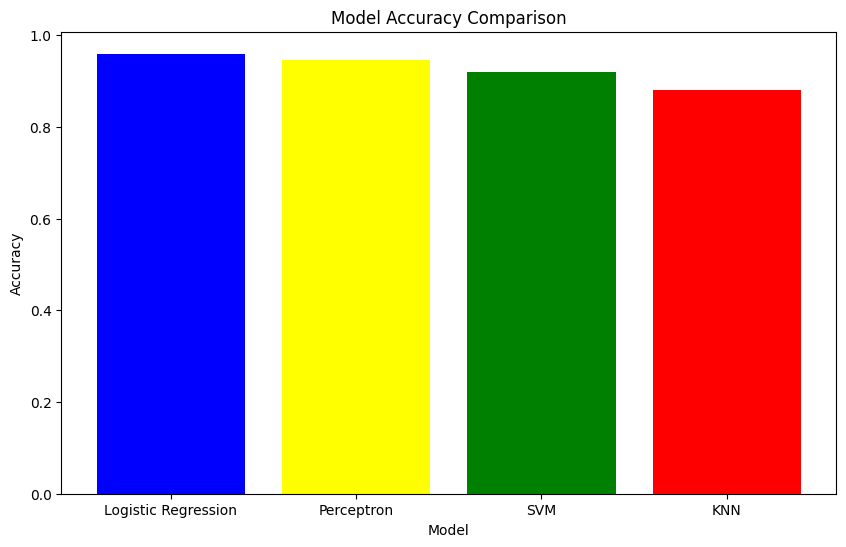

In [66]:
import matplotlib.pyplot as plt
model_names = list(model_predictions.keys())
accuracies = [accuracy_score(y_test, y_pred) for y_pred in model_predictions.values()]
plt.figure(figsize=(10, 6))
plt.bar(model_names, accuracies, color=['blue', 'yellow','green','red'])
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.show()

Logistic Regression
Iteration 1: Accuracy = 0.946667
Iteration 2: Accuracy = 0.973333
Iteration 3: Accuracy = 0.960000
Iteration 4: Accuracy = 0.973333
Iteration 5: Accuracy = 0.973333
Iteration 6: Accuracy = 0.973333
Iteration 7: Accuracy = 0.973333
Iteration 8: Accuracy = 0.973333
Iteration 9: Accuracy = 0.960000
Iteration 10: Accuracy = 0.973333
Mean Accuracy : 0.968000


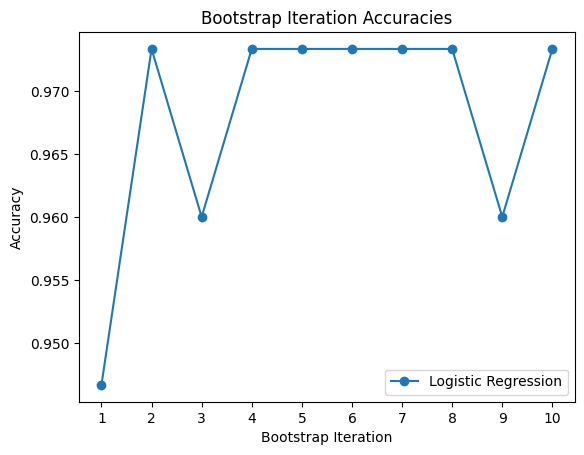

In [67]:
models = {
    'Logistic Regression': LogisticRegression(),
}

n_bootstrap_samples = 10
model_predictions = {model_name:[] for model_name in models}
model_accuracies = {}
for model_name, model in models.items():
  print (model_name)
  bootstrap_preds = []
  iteration_accuracies = []
  for i in range(1, n_bootstrap_samples + 1):
    x_resampled, y_resampled = resample(x_train_scaled, y_train)
    model.fit(x_resampled, y_resampled)
    y_pred = model.predict(x_test_scaled)
    bootstrap_preds.append(y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    iteration_accuracies.append(accuracy)
    print(f"Iteration {i}: Accuracy = {accuracy:5f}")
  mean_accuracy = np.mean(iteration_accuracies)
  print(f"Mean Accuracy : {mean_accuracy:3f}")
  model_accuracies[model_name] = iteration_accuracies

for model_name, accuracies in model_accuracies.items():
  plt.plot(range(1, n_bootstrap_samples + 1), accuracies, marker='o',label=model_name)
  plt.title("Bootstrap Iteration Accuracies")
  plt.xlabel("Bootstrap Iteration")
  plt.ylabel("Accuracy")
  plt.xticks(range(1, n_bootstrap_samples + 1))
  plt.legend()
  plt.show()

perceptron
Iteration 1: Accuracy = 0.93333
Iteration 2: Accuracy = 0.90667
Iteration 3: Accuracy = 0.94667
Iteration 4: Accuracy = 0.94667
Iteration 5: Accuracy = 0.90667
Iteration 6: Accuracy = 0.93333
Iteration 7: Accuracy = 0.94667
Iteration 8: Accuracy = 0.89333
Iteration 9: Accuracy = 0.90667
Iteration 10: Accuracy = 0.92000
Mean Accuracy: 0.924


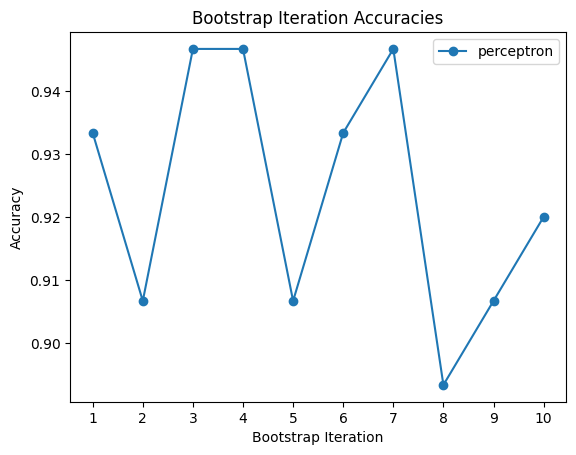

In [68]:
models = {
'perceptron': Perceptron()
}
n_bootstrap_samples = 10
model_accuracies = {model_name: [] for model_name in models}
for model_name, model in models.items():
  print(model_name)
  bootstrap_preds = []
  iteration_accuracies = []
  for iteration in range(1, n_bootstrap_samples + 1):
    # The following lines were not indented and caused the error
    x_resampled, y_resampled = resample(x_train_scaled, y_train)
    model.fit(x_resampled, y_resampled)
    y_pred = model.predict(x_test_scaled)
    bootstrap_preds.append(y_pred)
    acc = accuracy_score(y_test, y_pred)
    iteration_accuracies.append(acc)
    print(f"Iteration {iteration}: Accuracy = {acc:.5f}")
  mean_accuracy = np.mean(iteration_accuracies)
  print(f"Mean Accuracy: {mean_accuracy:.3f}")
  model_accuracies[model_name] = iteration_accuracies
for model_name, accuracies in model_accuracies.items():
    plt.plot(range(1, n_bootstrap_samples + 1), accuracies, marker='o', label=model_name)
plt.title("Bootstrap Iteration Accuracies")
plt.xlabel("Bootstrap Iteration")
plt.ylabel("Accuracy")
plt.xticks(range(1, n_bootstrap_samples + 1))
plt.legend()
plt.show()

SVM
Iteration 1: Accuracy = 0.92000
Iteration 2: Accuracy = 0.92000
Iteration 3: Accuracy = 0.93333
Iteration 4: Accuracy = 0.93333
Iteration 5: Accuracy = 0.93333
Iteration 6: Accuracy = 0.90667
Iteration 7: Accuracy = 0.93333
Iteration 8: Accuracy = 0.93333
Iteration 9: Accuracy = 0.93333
Iteration 10: Accuracy = 0.93333
Mean Accuracy: 0.928


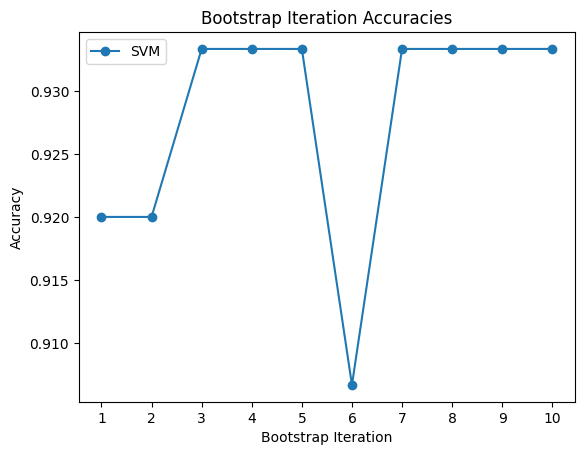

In [69]:
models = {
'SVM': SVC()
}
n_bootstrap_samples = 10
model_accuracies = {model_name: [] for model_name in models}
for model_name, model in models.items():
    print(model_name)
    bootstrap_preds = []
    iteration_accuracies = []
    for iteration in range(1, n_bootstrap_samples + 1):
        x_resampled, y_resampled = resample(x_train_scaled, y_train)
        model.fit(x_resampled, y_resampled)
        y_pred = model.predict(x_test_scaled)
        bootstrap_preds.append(y_pred)
        acc = accuracy_score(y_test, y_pred)
        iteration_accuracies.append(acc)
        print(f"Iteration {iteration}: Accuracy = {acc:.5f}")
    mean_accuracy = np.mean(iteration_accuracies)
    print(f"Mean Accuracy: {mean_accuracy:.3f}")
    model_accuracies[model_name] = iteration_accuracies
for model_name, accuracies in model_accuracies.items():
    plt.plot(range(1, n_bootstrap_samples + 1), accuracies, marker='o',label=model_name)
plt.title("Bootstrap Iteration Accuracies")
plt.xlabel("Bootstrap Iteration")
plt.ylabel("Accuracy")
plt.xticks(range(1, n_bootstrap_samples + 1))
plt.legend()
plt.show()

KNN
Iteration 1: Accuracy = 0.88000
Iteration 2: Accuracy = 0.89333
Iteration 3: Accuracy = 0.86667
Iteration 4: Accuracy = 0.90667
Iteration 5: Accuracy = 0.93333
Iteration 6: Accuracy = 0.89333
Iteration 7: Accuracy = 0.86667
Iteration 8: Accuracy = 0.90667
Iteration 9: Accuracy = 0.86667
Iteration 10: Accuracy = 0.89333
Mean Accuracy: 0.890667


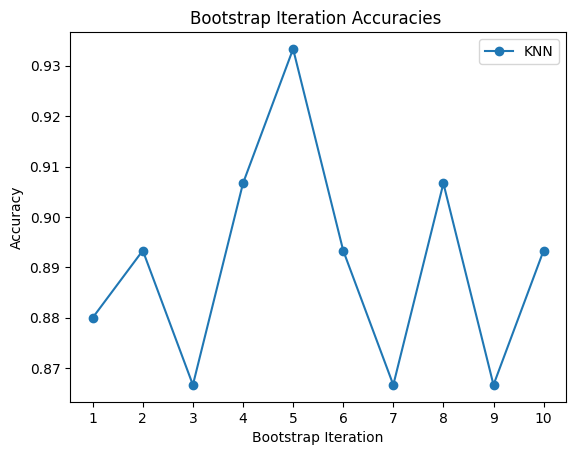

In [70]:
models = {
'KNN': KNeighborsClassifier()
}
n_bootstrap_samples = 10
model_accuracies = {model_name: [] for model_name in models}
for model_name, model in models.items():
    print(model_name) # This line and the subsequent lines within the loop need to be indented
    bootstrap_preds = []
    iteration_accuracies = []
    for iteration in range(1, n_bootstrap_samples + 1):
        x_resampled, y_resampled = resample(x_train_scaled, y_train)
        model.fit(x_resampled, y_resampled)
        y_pred = model.predict(x_test_scaled)
        bootstrap_preds.append(y_pred)
        acc = accuracy_score(y_test, y_pred)
        iteration_accuracies.append(acc)
        print(f"Iteration {iteration}: Accuracy = {acc:.5f}")
    mean_accuracy = np.mean(iteration_accuracies)
    print(f"Mean Accuracy: {mean_accuracy:3f}")
    model_accuracies[model_name] = iteration_accuracies
for model_name, accuracies in model_accuracies.items():
    plt.plot(range(1, n_bootstrap_samples + 1), accuracies, marker='o', label=model_name)
plt.title("Bootstrap Iteration Accuracies ")
plt.xlabel("Bootstrap Iteration")
plt.ylabel("Accuracy")
plt.xticks(range(1, n_bootstrap_samples + 1))
plt.legend()
plt.show()